# PZTO-(111) MOBO-DKL experiment replay and materials analysis

This Colab-compatible notebook reproduces the public PZTO-(111) voltage-dwell analysis from 427 destructive lateral-PFM writing measurements. It:

1. downloads and validates the compact release data;
2. recomputes the whole-frame and center-localized switched areas from the before/after maps;
3. extracts the switched-area versus pulse-dose Pareto front;
4. reproduces the descriptor and VAE structure-efficiency trends;
5. trains reward-specific deep-kernel Gaussian-process surrogates and uses qLogEHVI to recommend a held-out recorded candidate in replay mode; and
6. provides a minimal instrument-adapter interface for a live implementation.

The replay uses only measurements that already occurred. It does not claim to reconstruct the exact historical acquisition path, because the complete unmeasured candidate maps were not exported from the microscope. The pulse dose `|V|t` is a write-dose proxy, not electrical energy.


## 1. Environment

The tested package versions are recorded in `requirements.txt`. Colab already provides PyTorch, NumPy, SciPy, pandas and Matplotlib; the next cell installs the version-sensitive MOBO dependencies only when needed.


In [1]:
import importlib.util
import subprocess
import sys

IN_COLAB = "google.colab" in sys.modules
required = {
    "gpytorch": "gpytorch==1.14.3",
    "botorch": "botorch==0.16.1",
    "skimage": "scikit-image==0.25.2",
    "sklearn": "scikit-learn==1.7.2",
}
missing = [spec for module, spec in required.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
print("Colab:", IN_COLAB, "| dependency installation:", "completed" if missing else "already satisfied")


Colab: False | dependency installation: already satisfied


In [2]:
from __future__ import annotations

import hashlib
import math
import os
import random
import urllib.request
from dataclasses import dataclass
from pathlib import Path
from typing import Protocol

import botorch
import gpytorch
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import sklearn
import skimage
import torch
from scipy import ndimage as ndi
from scipy.stats import spearmanr
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

SEED = 0
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 9,
    "axes.linewidth": 0.8,
    "axes.spines.top": True,
    "axes.spines.right": True,
    "figure.dpi": 130,
})

print("Python", sys.version.split()[0])
print("torch", torch.__version__, "| gpytorch", gpytorch.__version__, "| botorch", botorch.__version__)
print("numpy", np.__version__, "| scipy", scipy.__version__, "| sklearn", sklearn.__version__)


Python 3.10.19
torch 2.9.1 | gpytorch 1.14.3 | botorch 0.16.1
numpy 2.2.6 | scipy 1.15.3 | sklearn 1.7.2


## 2. Download and validate the compact data

When opened from GitHub in Colab, the notebook downloads three files from the same repository. When run from a local clone, the existing `data/` directory is used.


In [3]:
RAW_BASE = "https://raw.githubusercontent.com/RichardLiuCoding/Publications/main/MOBO-DKL"
DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

FILES = [
    "PZTO111_MOBO_DKL_maps_v1.npz",
    "PZTO111_MOBO_DKL_analysis_v1.npz",
    "PZTO111_MOBO_DKL_events_v1.csv.gz",
]
for filename in FILES:
    destination = DATA_DIR / filename
    if not destination.exists():
        url = f"{RAW_BASE}/data/{filename}"
        print("Downloading", url)
        urllib.request.urlretrieve(url, destination)

def sha256(path):
    digest = hashlib.sha256()
    with open(path, "rb") as stream:
        for block in iter(lambda: stream.read(1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()

for filename in FILES:
    path = DATA_DIR / filename
    print(f"{filename}: {path.stat().st_size / 1024**2:.2f} MB | SHA256 {sha256(path)[:16]}...")


PZTO111_MOBO_DKL_maps_v1.npz: 6.11 MB | SHA256 fc25809833fb908e...
PZTO111_MOBO_DKL_analysis_v1.npz: 3.13 MB | SHA256 0148a7aef2c9ad5d...
PZTO111_MOBO_DKL_events_v1.csv.gz: 0.06 MB | SHA256 d571c92a2177b6fc...


In [4]:
maps = np.load(DATA_DIR / "PZTO111_MOBO_DKL_maps_v1.npz", allow_pickle=False)
analysis = np.load(DATA_DIR / "PZTO111_MOBO_DKL_analysis_v1.npz", allow_pickle=False)
events = pd.read_csv(DATA_DIR / "PZTO111_MOBO_DKL_events_v1.csv.gz")

assert len(events) == 427
assert maps["phase_before_deg"].shape == (427, 32, 32)
assert analysis["descriptor_matrix"].shape == (427, 15)
assert np.array_equal(events["event_id"].to_numpy(), np.arange(427))

print(events.groupby("area_name").agg(
    measurements=("event_id", "size"),
    seeds=("is_seed", "sum"),
    voltage_min=("voltage_V", "min"),
    voltage_max=("voltage_V", "max"),
    dwell_min=("dwell_s", "min"),
    dwell_max=("dwell_s", "max"),
))


           measurements  seeds  voltage_min  voltage_max  dwell_min  dwell_max
area_name                                                                     
Area 1              215     15         -6.0          6.0        0.5       10.0
Area 2              212     12         -6.0          5.5        0.5       10.0


## 3. Switched-area extraction

A switched pixel must pass both tests: wrapped absolute phase change greater than 45 degrees and absolute after-pulse amplitude greater than half the frame median. A peripheral median phase change above 120 degrees triggers a global 180-degree resonance-offset correction. The primary area retains four-connected components that touch a four-pixel-radius central disk; if none touch, it retains the nearest component whose centroid lies within eight pixels of the center.


In [5]:
def wrapped_phase_difference(after, before):
    return np.abs((after - before + 180.0) % 360.0 - 180.0)

def extract_switched_masks(amplitude_after, phase_after, phase_before,
                           phase_threshold=45.0, amplitude_gate=0.5,
                           flip_threshold=120.0, central_radius=4.0,
                           link_radius=8.0):
    height, width = phase_before.shape
    yy, xx = np.mgrid[:height, :width]
    guard_center = ((xx - width // 2) ** 2 + (yy - height // 2) ** 2) < 20.0**2
    raw = wrapped_phase_difference(phase_after, phase_before)
    flipped = bool(np.median(raw[~guard_center]) > flip_threshold)
    corrected_after = phase_after - 180.0 if flipped else phase_after
    difference = wrapped_phase_difference(corrected_after, phase_before)
    absolute_amplitude = np.abs(amplitude_after)
    amplitude_ok = absolute_amplitude > amplitude_gate * np.median(absolute_amplitude)
    whole = (difference > phase_threshold) & amplitude_ok

    labels, count = ndi.label(whole)  # four-connectivity is the SciPy default
    localized = np.zeros_like(whole)
    if count == 0:
        return whole, localized, difference, flipped
    center_y, center_x = (height - 1) / 2.0, (width - 1) / 2.0
    radius = np.hypot(yy - center_y, xx - center_x)
    central_labels = set(labels[(radius <= central_radius) & whole]) - {0}
    if central_labels:
        localized = np.isin(labels, list(central_labels))
    else:
        best_label, best_distance = 0, np.inf
        for component in range(1, count + 1):
            ys, xs = np.where(labels == component)
            distance = np.hypot(ys.mean() - center_y, xs.mean() - center_x)
            if distance < best_distance:
                best_label, best_distance = component, distance
        if best_distance <= link_radius:
            localized = labels == best_label
    return whole, localized, difference, flipped

recomputed_full = []
recomputed_localized = []
for amp_after, phase_after, phase_before in zip(
    maps["amplitude_after"], maps["phase_after_deg"], maps["phase_before_deg"]
):
    whole, localized, _, _ = extract_switched_masks(amp_after, phase_after, phase_before)
    recomputed_full.append(whole.sum())
    recomputed_localized.append(localized.sum())

recomputed_full = np.asarray(recomputed_full)
recomputed_localized = np.asarray(recomputed_localized)
assert np.array_equal(recomputed_full, events["switched_area_full_px"])
assert np.array_equal(recomputed_localized, events["switched_area_localized_px"])
print("Exact event-by-event agreement for all 427 switched-area measurements.")


Exact event-by-event agreement for all 427 switched-area measurements.


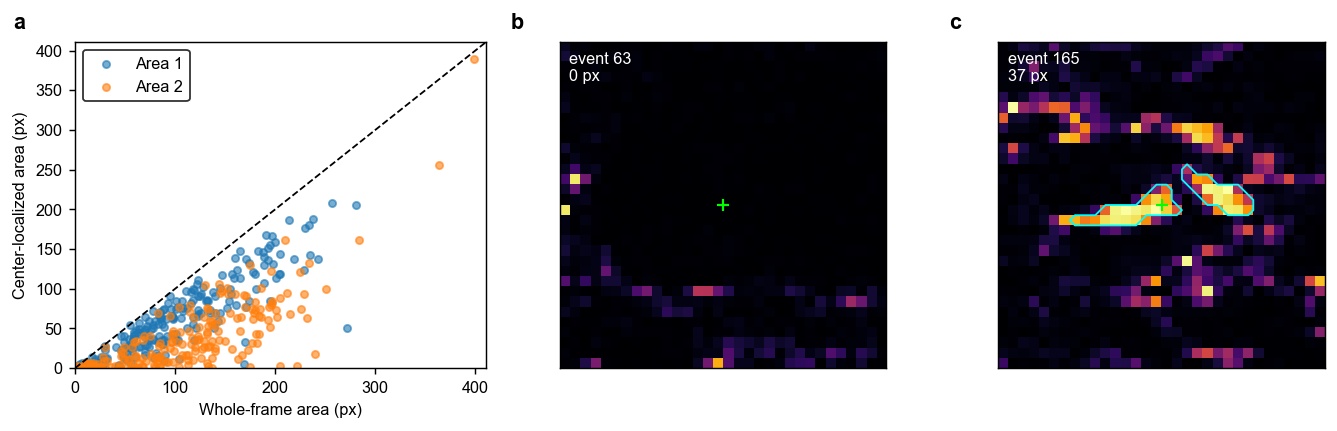

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(10.5, 3.2), constrained_layout=True)
for area_name, group in events.groupby("area_name"):
    axes[0].scatter(group["switched_area_full_px"], group["switched_area_localized_px"],
                    s=16, alpha=0.60, label=area_name)
limit = 1.03 * events["switched_area_full_px"].max()
axes[0].plot([0, limit], [0, limit], "k--", lw=1)
axes[0].set(xlim=(0, limit), ylim=(0, limit), xlabel="Whole-frame area (px)",
            ylabel="Center-localized area (px)")
axes[0].legend(frameon=True, edgecolor="black")

example_ids = [
    int(events["switched_area_localized_px"].idxmin()),
    int((events["switched_area_localized_px"] - events["switched_area_localized_px"].median()).abs().idxmin()),
]
for ax, event_id in zip(axes[1:], example_ids):
    whole, localized, difference, _ = extract_switched_masks(
        maps["amplitude_after"][event_id], maps["phase_after_deg"][event_id], maps["phase_before_deg"][event_id]
    )
    ax.imshow(difference, origin="lower", cmap="inferno", vmin=0, vmax=180)
    if localized.any():
        ax.contour(localized, levels=[0.5], colors="cyan", linewidths=1.0)
    ax.plot(15.5, 15.5, "+", color="lime", ms=7, mew=1.2)
    ax.set(xticks=[], yticks=[])
    ax.text(0.03, 0.97, f"event {event_id}\n{int(localized.sum())} px",
            transform=ax.transAxes, va="top", color="white")
for label, ax in zip("abc", axes):
    ax.text(-0.15, 1.04, label, transform=ax.transAxes, fontweight="bold", fontsize=12)
plt.show()


## 4. Pulse-dose Pareto front

The front below minimizes `|V|t` while maximizing center-localized switched area. It is an empirical front over measured events, not a claim that `|V|t` equals electrical energy.


,event_id,area_name,voltage_V,dwell_s,pulse_dose_Vs,switched_area_localized_um2,write_dose_efficiency_um2_per_Vs
0,0,Area 1,3.0,0.5,1.5,0.003174,0.002116
106,106,Area 1,5.0,0.5,2.5,0.050781,0.020313
332,332,Area 2,-4.5,10.0,45.0,0.094971,0.002110


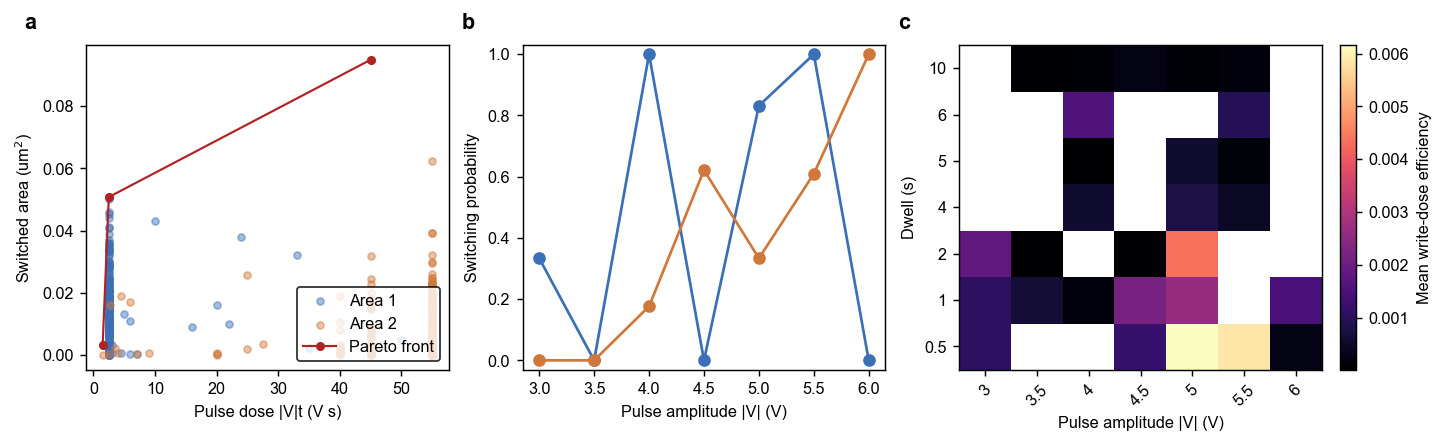

In [7]:
def pareto_min_dose_max_area(frame):
    ordered = frame.sort_values(["pulse_dose_Vs", "switched_area_localized_um2"],
                                ascending=[True, False]).copy()
    best_area = -np.inf
    keep = []
    for area in ordered["switched_area_localized_um2"]:
        keep.append(area > best_area)
        best_area = max(best_area, area)
    return ordered.loc[keep].copy()

front = pareto_min_dose_max_area(events)
display(front[["event_id", "area_name", "voltage_V", "dwell_s", "pulse_dose_Vs",
               "switched_area_localized_um2", "write_dose_efficiency_um2_per_Vs"]])

fig, axes = plt.subplots(1, 3, figsize=(11.0, 3.3), constrained_layout=True)
colors = {"Area 1": "#3B6FB6", "Area 2": "#D0783C"}
for area_name, group in events.groupby("area_name"):
    axes[0].scatter(group["pulse_dose_Vs"], group["switched_area_localized_um2"],
                    s=15, alpha=0.45, color=colors[area_name], label=area_name)
axes[0].plot(front["pulse_dose_Vs"], front["switched_area_localized_um2"],
             "o-", color="#B22222", ms=4, lw=1.2, label="Pareto front")
axes[0].set(xlabel="Pulse dose |V|t (V s)", ylabel="Switched area (um$^2$)")
axes[0].legend(frameon=True, edgecolor="black", loc="lower right")

bins = np.arange(2.75, 6.26, 0.5)
centers = 0.5 * (bins[:-1] + bins[1:])
for area_name, group in events.groupby("area_name"):
    probability = [
        (group.loc[(group["abs_voltage_V"] >= lo) & (group["abs_voltage_V"] < hi),
                   "switched_area_localized_px"] > 15).mean()
        for lo, hi in zip(bins[:-1], bins[1:])
    ]
    axes[1].plot(centers, probability, "o-", color=colors[area_name], label=area_name)
axes[1].set(xlabel="Pulse amplitude |V| (V)", ylabel="Switching probability", ylim=(-0.03, 1.03))

heat = events.pivot_table(index="dwell_s", columns="abs_voltage_V",
                          values="write_dose_efficiency_um2_per_Vs", aggfunc="mean")
image = axes[2].imshow(heat.values, origin="lower", aspect="auto", cmap="magma")
axes[2].set_xticks(range(len(heat.columns)), [f"{v:g}" for v in heat.columns], rotation=45)
axes[2].set_yticks(range(len(heat.index)), [f"{v:g}" for v in heat.index])
axes[2].set(xlabel="Pulse amplitude |V| (V)", ylabel="Dwell (s)")
plt.colorbar(image, ax=axes[2], label="Mean write-dose efficiency")
for label, ax in zip("abc", axes):
    ax.text(-0.17, 1.05, label, transform=ax.transAxes, fontweight="bold", fontsize=12)
plt.show()


## 5. Descriptor analysis of the before-pulse structure

The 15 descriptors were computed from the before-pulse lateral-PFM maps only. PCA is refit below after z-scoring. Because PCA signs are arbitrary, PC1 is oriented so that increasing PC1 corresponds to increasing switched area.


PC1 explained variance = 0.373
Spearman rho(PC1, center-localized area) = 0.631


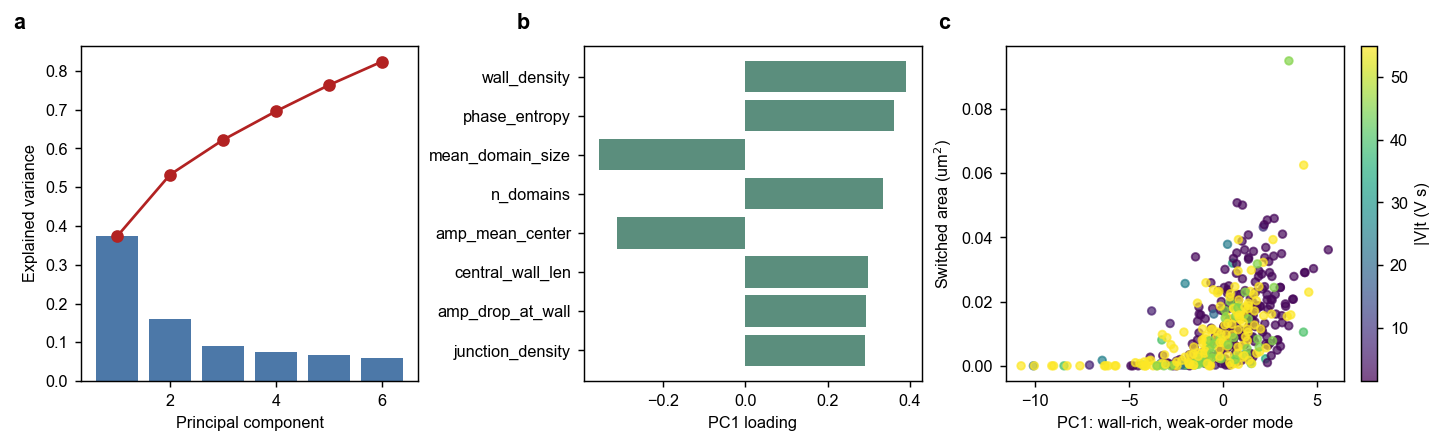

In [8]:
descriptor_names = analysis["descriptor_names"].astype(str)
descriptor_matrix = analysis["descriptor_matrix"].astype(float)
standardized = StandardScaler().fit_transform(descriptor_matrix)
standardized = np.nan_to_num(standardized, nan=0.0, posinf=0.0, neginf=0.0)
pca = PCA(n_components=6, random_state=SEED, svd_solver="full")
scores = pca.fit_transform(standardized)

area_px = events["switched_area_localized_px"].to_numpy(float)
if spearmanr(scores[:, 0], area_px).statistic < 0:
    scores[:, 0] *= -1
    pca.components_[0] *= -1

rho_pc1 = spearmanr(scores[:, 0], area_px).statistic
print(f"PC1 explained variance = {pca.explained_variance_ratio_[0]:.3f}")
print(f"Spearman rho(PC1, center-localized area) = {rho_pc1:.3f}")

fig, axes = plt.subplots(1, 3, figsize=(11.0, 3.3), constrained_layout=True)
axes[0].bar(np.arange(1, 7), pca.explained_variance_ratio_, color="#4C78A8")
axes[0].plot(np.arange(1, 7), np.cumsum(pca.explained_variance_ratio_), "o-", color="#B22222")
axes[0].set(xlabel="Principal component", ylabel="Explained variance")

loading_order = np.argsort(np.abs(pca.components_[0]))[-8:]
axes[1].barh(np.arange(len(loading_order)), pca.components_[0, loading_order], color="#5B8E7D")
axes[1].set_yticks(np.arange(len(loading_order)), descriptor_names[loading_order])
axes[1].set(xlabel="PC1 loading")

scatter = axes[2].scatter(scores[:, 0], area_px * float(maps["um2_per_pixel"]),
                          c=events["pulse_dose_Vs"], cmap="viridis", s=18, alpha=0.70)
axes[2].set(xlabel="PC1: wall-rich, weak-order mode", ylabel="Switched area (um$^2$)")
plt.colorbar(scatter, ax=axes[2], label="|V|t (V s)")
for label, ax in zip("abc", axes):
    ax.text(-0.20, 1.05, label, transform=ax.transAxes, fontweight="bold", fontsize=12)
plt.show()


## 6. VAE structure-efficiency analysis

The release includes the manuscript VAE inputs, reconstructions, six-dimensional latent means and two-dimensional PCA projection. The VAE was unsupervised: it received no voltage, dwell, switched area or efficiency. The fixed-dose cohort (`|V| = 5 V`, `t = 0.5 s`) isolates the effect of the starting texture.


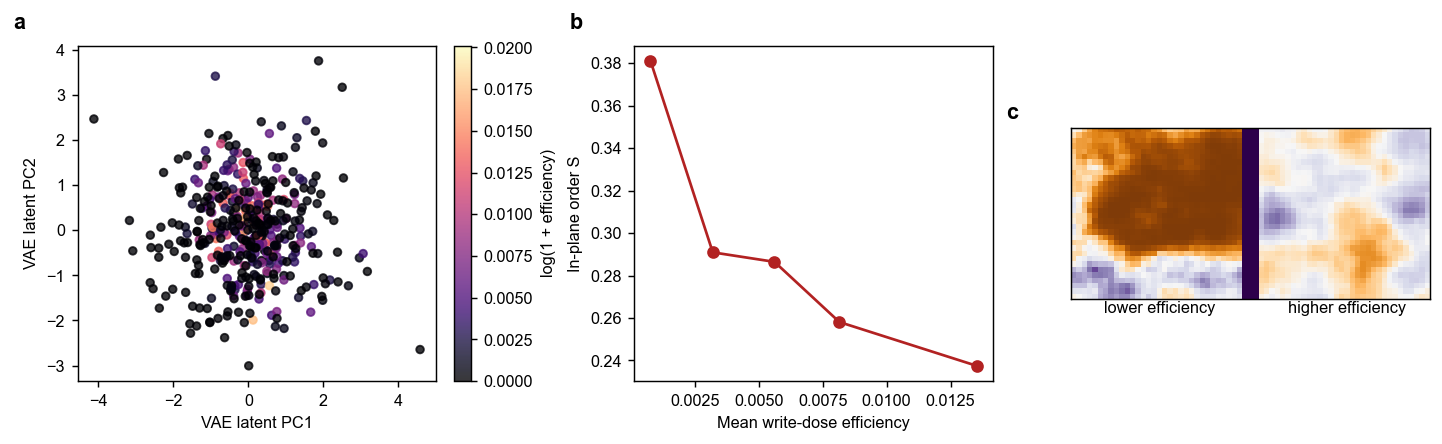

Fixed-dose n = 199 | Spearman rho(S, efficiency) = -0.523


In [9]:
fixed = events[(events["abs_voltage_V"] == 5.0) & (events["dwell_s"] == 0.5)].copy()
assert len(fixed) == 199

fig, axes = plt.subplots(1, 3, figsize=(11.0, 3.3), constrained_layout=True)
latent = analysis["vae_latent_pca_2d"]
scatter = axes[0].scatter(latent[:, 0], latent[:, 1],
                          c=np.log1p(events["write_dose_efficiency_um2_per_Vs"]),
                          cmap="magma", s=18, alpha=0.78)
axes[0].set(xlabel="VAE latent PC1", ylabel="VAE latent PC2")
plt.colorbar(scatter, ax=axes[0], label="log(1 + efficiency)")

quantiles = pd.qcut(fixed["write_dose_efficiency_um2_per_Vs"], 5, labels=False, duplicates="drop")
summary = fixed.assign(efficiency_quintile=quantiles).groupby("efficiency_quintile").agg(
    efficiency=("write_dose_efficiency_um2_per_Vs", "mean"),
    order_S=("in_plane_order_S", "mean"),
)
axes[1].plot(summary["efficiency"], summary["order_S"], "o-", color="#B22222")
axes[1].set(xlabel="Mean write-dose efficiency", ylabel="In-plane order S")

low_id = int(fixed["write_dose_efficiency_um2_per_Vs"].idxmin())
high_id = int(fixed["write_dose_efficiency_um2_per_Vs"].idxmax())
comparison = np.concatenate([
    analysis["vae_reconstruction"][low_id],
    np.ones((32, 3)),
    analysis["vae_reconstruction"][high_id],
], axis=1)
axes[2].imshow(comparison, origin="lower", cmap="PuOr", vmin=0, vmax=1)
axes[2].set(xticks=[], yticks=[])
axes[2].text(16, -3, "lower efficiency", ha="center")
axes[2].text(51, -3, "higher efficiency", ha="center")
for label, ax in zip("abc", axes):
    ax.text(-0.18, 1.05, label, transform=ax.transAxes, fontweight="bold", fontsize=12)
plt.show()

rho_order = spearmanr(fixed["in_plane_order_S"], fixed["write_dose_efficiency_um2_per_Vs"]).statistic
print(f"Fixed-dose n = {len(fixed)} | Spearman rho(S, efficiency) = {rho_order:.3f}")


### Optional: retrain the manuscript VAE architecture

`FAST_MODE=True` uses 80 epochs for a short Colab check. Set it to `False` for the manuscript schedule of 500 epochs with beta ramped to 0.4 over the first 120 epochs. The precomputed reference outputs above remain the comparison target.


VAE finished 80 epochs on cpu | final loss 0.6931


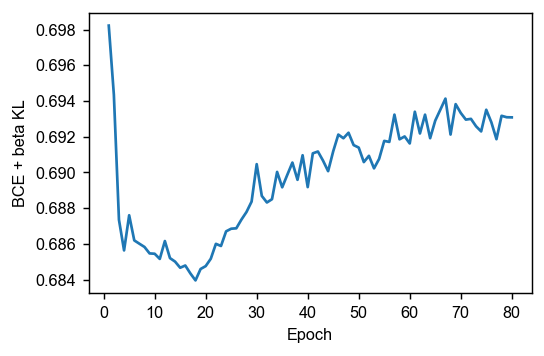

In [10]:
FAST_MODE = True
VAE_EPOCHS = 80 if FAST_MODE else 500

class ConvVAE(nn.Module):
    def __init__(self, latent_dim=6):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, 4, 2, 1), nn.ReLU(),
            nn.Conv2d(32, 64, 4, 2, 1), nn.ReLU(),
            nn.Conv2d(64, 128, 4, 2, 1), nn.ReLU(),
            nn.Conv2d(128, 256, 4, 2, 1), nn.ReLU(),
            nn.Flatten(),
        )
        self.fc_mu = nn.Linear(256 * 2 * 2, latent_dim)
        self.fc_logvar = nn.Linear(256 * 2 * 2, latent_dim)
        self.fc_decode = nn.Linear(latent_dim, 256 * 2 * 2)
        self.decoder = nn.Sequential(
            nn.Unflatten(1, (256, 2, 2)),
            nn.ConvTranspose2d(256, 128, 4, 2, 1), nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 4, 2, 1), nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, 2, 1), nn.ReLU(),
            nn.ConvTranspose2d(32, 1, 4, 2, 1), nn.Sigmoid(),
        )

    def encode(self, x):
        hidden = self.encoder(x)
        return self.fc_mu(hidden), self.fc_logvar(hidden).clamp(-8, 8)

    def forward(self, x):
        mu, logvar = self.encode(x)
        std = torch.exp(0.5 * logvar)
        latent = mu + torch.randn_like(std) * std
        return self.decoder(self.fc_decode(latent)), mu, logvar

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
vae_model = ConvVAE().to(device)
optimizer = torch.optim.Adam(vae_model.parameters(), lr=1e-3)
vae_tensor = torch.from_numpy(analysis["vae_input_normalized"][:, None]).float()
loader = DataLoader(TensorDataset(vae_tensor), batch_size=64, shuffle=True,
                    generator=torch.Generator().manual_seed(SEED))
history = []
for epoch in range(VAE_EPOCHS):
    vae_model.train()
    beta = 0.4 * min(1.0, (epoch + 1) / 120.0)
    running = 0.0
    for (batch,) in loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        reconstruction, mu, logvar = vae_model(batch)
        reconstruction_loss = nn.functional.binary_cross_entropy(reconstruction, batch)
        kl = -0.5 * torch.mean(1 + logvar - mu.square() - logvar.exp())
        loss = reconstruction_loss + beta * kl
        loss.backward()
        optimizer.step()
        running += float(loss.detach()) * len(batch)
    history.append(running / len(vae_tensor))

vae_model.eval()
with torch.no_grad():
    trained_mu, _ = vae_model.encode(vae_tensor.to(device))
trained_mu = trained_mu.cpu().numpy()
print(f"VAE finished {VAE_EPOCHS} epochs on {device} | final loss {history[-1]:.4f}")
plt.figure(figsize=(4.4, 2.8))
plt.plot(np.arange(1, VAE_EPOCHS + 1), history)
plt.xlabel("Epoch")
plt.ylabel("BCE + beta KL")
plt.show()


## 7. MOBO-DKL replay on held-out recorded candidates

The replay keeps the chronological first measurements from each area as observations and treats the remaining recorded events as a discrete candidate pool. Three reward-specific CNN-GP models learn center-localized switched area, signed before-pulse piezoresponse and negative pulse dose. qLogEHVI ranks the held-out candidates. Revealing the selected candidate's measured response emulates one active-learning step.

This is a reproducibility demonstration of the learning and decision logic. A live experiment must form candidates from unmeasured global-map patches and execute the selected pulse through an instrument adapter.


In [11]:
from botorch.acquisition.multi_objective.logei import qLogExpectedHypervolumeImprovement
from botorch.models.gpytorch import GPyTorchModel
from botorch.models.model_list_gp_regression import ModelListGP
from botorch.sampling.normal import SobolQMCNormalSampler
from botorch.utils.multi_objective.box_decompositions.non_dominated import FastNondominatedPartitioning

FAST_MODE = True
TRAIN_PER_AREA = 55 if FAST_MODE else 100
DKL_EPOCHS = 25 if FAST_MODE else 50
DTYPE = torch.float32 if FAST_MODE else torch.float64

image_input = analysis["vae_input_normalized"].astype(np.float32)
signed_voltage = events["voltage_V"].to_numpy(np.float32) / 6.0
log_dwell = np.log10(events["dwell_s"].to_numpy(np.float32)) / np.log10(10.0)
area_one_hot = np.eye(2, dtype=np.float32)[events["area_id"].to_numpy(int) - 1]
conditions = np.column_stack([signed_voltage, log_dwell, area_one_hot]).astype(np.float32)
all_inputs = np.column_stack([image_input.reshape(len(events), -1), conditions])

raw_targets = np.column_stack([
    events["switched_area_localized_um2"].to_numpy(float),
    events["before_piezoresponse_reward"].to_numpy(float),
    -events["pulse_dose_Vs"].to_numpy(float),
])

observed_mask = np.zeros(len(events), dtype=bool)
for area_id in [1, 2]:
    indices = events.index[events["area_id"] == area_id].to_numpy()
    observed_mask[indices[:TRAIN_PER_AREA]] = True
candidate_mask = ~observed_mask
observed_indices = np.where(observed_mask)[0]
candidate_indices = np.where(candidate_mask)[0]

target_mean = raw_targets[observed_mask].mean(axis=0)
target_std = raw_targets[observed_mask].std(axis=0) + 1e-12
standard_targets = (raw_targets - target_mean) / target_std

train_x = torch.as_tensor(all_inputs[observed_mask], dtype=DTYPE, device=device)
train_y = torch.as_tensor(standard_targets[observed_mask], dtype=DTYPE, device=device)
candidate_x = torch.as_tensor(all_inputs[candidate_mask], dtype=DTYPE, device=device)


In [12]:
IMAGE_PIXELS = 32 * 32
CONDITION_DIM = 4
LATENT_DIM = 2

class ImageConditionFeatures(nn.Module):
    def __init__(self):
        super().__init__()
        self.convolution = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Flatten(),
        )
        self.projection = nn.Linear(32 * 8 * 8, LATENT_DIM)

    def forward(self, x):
        leading_shape = x.shape[:-1]
        images = x[..., :IMAGE_PIXELS].reshape(-1, 1, 32, 32)
        conditions = x[..., IMAGE_PIXELS:]
        latent = self.projection(self.convolution(images)).reshape(*leading_shape, LATENT_DIM)
        return torch.cat([latent, conditions], dim=-1)

class DKLExactGP(gpytorch.models.ExactGP, GPyTorchModel):
    _num_outputs = 1

    def __init__(self, train_inputs, train_target, likelihood):
        super().__init__(train_inputs, train_target, likelihood)
        self.feature_extractor = ImageConditionFeatures()
        self.mean_module = gpytorch.means.ConstantMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(
            gpytorch.kernels.RBFKernel(ard_num_dims=LATENT_DIM + CONDITION_DIM)
        )

    def forward(self, x):
        features = self.feature_extractor(x)
        mean = self.mean_module(features)
        covariance = self.covar_module(features)
        return gpytorch.distributions.MultivariateNormal(mean, covariance)

def fit_reward_model(x, y, epochs):
    likelihood = gpytorch.likelihoods.GaussianLikelihood().to(device=device, dtype=DTYPE)
    model = DKLExactGP(x, y, likelihood).to(device=device, dtype=DTYPE)
    model.train()
    likelihood.train()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
    marginal_likelihood = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)
    for _ in range(epochs):
        optimizer.zero_grad()
        output = model(x)
        loss = -marginal_likelihood(output, y)
        loss.backward()
        optimizer.step()
    model.eval()
    likelihood.eval()
    return model

models = [fit_reward_model(train_x, train_y[:, objective], DKL_EPOCHS) for objective in range(3)]
model_list = ModelListGP(*models)
print(f"Trained 3 DKL surrogates on {len(train_x)} observations for {DKL_EPOCHS} epochs each.")


Trained 3 DKL surrogates on 110 observations for 25 epochs each.


Recommended held-out event


,event_id,area_name,measurement_order,voltage_V,dwell_s,pulse_dose_Vs,switched_area_localized_um2,write_dose_efficiency_um2_per_Vs
73,73,Area 1,73,5.0,0.5,2.5,0.006836,0.002734


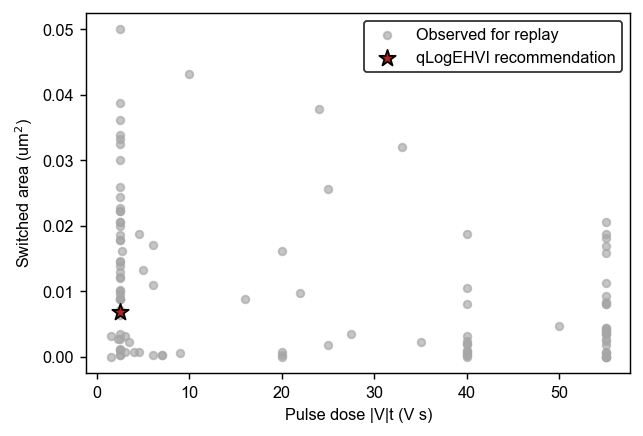

In [13]:
reference = train_y.min(dim=0).values - 0.1
partitioning = FastNondominatedPartitioning(ref_point=reference, Y=train_y)
acquisition = qLogExpectedHypervolumeImprovement(
    model=model_list,
    ref_point=reference.tolist(),
    partitioning=partitioning,
    sampler=SobolQMCNormalSampler(sample_shape=torch.Size([64]), seed=SEED),
)

acquisition_values = []
with torch.no_grad():
    for start in range(0, len(candidate_x), 64):
        batch = candidate_x[start:start + 64].unsqueeze(1)
        acquisition_values.append(acquisition(batch).cpu())
acquisition_values = torch.cat(acquisition_values).numpy()
selected_pool_index = int(np.argmax(acquisition_values))
selected_event_id = int(candidate_indices[selected_pool_index])
selected = events.loc[selected_event_id]

print("Recommended held-out event")
display(selected[["event_id", "area_name", "measurement_order", "voltage_V", "dwell_s",
                  "pulse_dose_Vs", "switched_area_localized_um2",
                  "write_dose_efficiency_um2_per_Vs"]].to_frame().T)

fig, ax = plt.subplots(figsize=(5.4, 3.6))
ax.scatter(events.loc[observed_mask, "pulse_dose_Vs"],
           events.loc[observed_mask, "switched_area_localized_um2"],
           s=18, color="0.65", alpha=0.65, label="Observed for replay")
ax.scatter(selected["pulse_dose_Vs"], selected["switched_area_localized_um2"],
           s=90, marker="*", color="#B22222", edgecolor="black", label="qLogEHVI recommendation")
ax.set(xlabel="Pulse dose |V|t (V s)", ylabel="Switched area (um$^2$)")
ax.legend(frameon=True, edgecolor="black")
plt.show()


## 8. Live-instrument adapter

The following interface separates the transferable MOBO-DKL loop from instrument-specific control. A laboratory deployment must implement the four adapter methods, validate channel names and units, add voltage and contact-force safety limits, and test on a sacrificial region. The cell defines the interface but does not contact hardware.


In [14]:
@dataclass(frozen=True)
class Candidate:
    x_px: int
    y_px: int
    voltage_V: float
    dwell_s: float

class SPMAdapter(Protocol):
    def move_tip(self, x_px: int, y_px: int) -> None: ...
    def acquire_lateral_pfm(self) -> tuple[np.ndarray, np.ndarray]: ...
    def apply_out_of_plane_pulse(self, voltage_V: float, dwell_s: float) -> None: ...
    def save_checkpoint(self, record: dict) -> None: ...

def gaussian_weighted_piezoresponse(amplitude, phase_deg):
    signed = amplitude * np.cos(np.deg2rad(phase_deg))
    height, width = signed.shape
    yy, xx = np.mgrid[:height, :width]
    cy, cx = (height - 1) / 2.0, (width - 1) / 2.0
    sigma = height / 2.0
    weights = np.exp(-((xx - cx) ** 2 + (yy - cy) ** 2) / (2 * sigma**2))
    return float(np.sum(signed * weights) / np.sum(weights))

def execute_candidate(adapter: SPMAdapter, candidate: Candidate):
    adapter.move_tip(candidate.x_px, candidate.y_px)
    amp_before, phase_before = adapter.acquire_lateral_pfm()
    adapter.apply_out_of_plane_pulse(candidate.voltage_V, candidate.dwell_s)
    amp_after, phase_after = adapter.acquire_lateral_pfm()
    whole, localized, difference, flipped = extract_switched_masks(
        amp_after, phase_after, phase_before
    )
    record = {
        "candidate": candidate,
        "switched_area_full_px": int(whole.sum()),
        "switched_area_localized_px": int(localized.sum()),
        "before_piezoresponse_reward": gaussian_weighted_piezoresponse(amp_before, phase_before),
        "pulse_dose_Vs": abs(candidate.voltage_V) * candidate.dwell_s,
        "phase_flip_corrected": flipped,
        "amplitude_before": amp_before,
        "phase_before_deg": phase_before,
        "amplitude_after": amp_after,
        "phase_after_deg": phase_after,
    }
    adapter.save_checkpoint(record)
    return record

print("Instrument adapter defined. No hardware command was executed.")


Instrument adapter defined. No hardware command was executed.


## 9. Reproducibility summary

- Area 1: 15 seed measurements plus 200 MOBO-DKL measurements.
- Area 2: 12 seed measurements plus 200 MOBO-DKL measurements.
- Local scan: 500 nm by 500 nm, 32 by 32 pixels.
- Pulse amplitudes: signed values between 3 and 6 V in magnitude.
- Dwell times: 0.5-10 s.
- Switched-area threshold: 45-degree wrapped phase change plus a 0.5-median amplitude gate.
- Primary area: center-localized four-connected components.
- VAE: six latent dimensions, unsupervised, with a 500-epoch full schedule.
- Online manuscript models: independent reward-specific CNN-GP surrogates updated for 50 Adam iterations per acquisition step.

See `data/DATA_DICTIONARY.md` for the schema and `README.md` for notebook-level provenance.
